In [6]:
#session 11 1
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

data = {
    'review': [
        'This product is amazing! I love it.',
        'Terrible quality, very disappointed.',
        'Works great, highly recommended.',
        'Not what I expected, waste of money.',
        'Fantastic value for money, very happy.',
        'Broken on arrival, completely unusable.',
        'Good product, but slow delivery.',
        'Excellent service and fast shipping.',
        'Worst purchase ever, avoid at all costs.',
        'Decent for the price, no complaints.'
    ],
    'sentiment': [
        'positive', 'negative', 'positive', 'negative', 'positive',
        'negative', 'positive', 'positive', 'negative', 'positive'
    ]
}

df = pd.DataFrame(data)
display(df.head())

vectorizer = CountVectorizer()

x = vectorizer.fit_transform(df['review'])
y = df['sentiment']

print(x.shape)
print(vectorizer.get_feature_names_out()[:10])

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print( x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

knn_classifier = KNeighborsClassifier(n_neighbors=3)

knn_classifier.fit(x_train, y_train)

y_pred = knn_classifier.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print( accuracy)
print(classification_report(y_test, y_pred))

new_reviews = [
    "This is a decent product for the price.",
    "Absolutely hated it, what a rip-off!"
]

new_reviews_vectorized = vectorizer.transform(new_reviews)

new_predictions = knn_classifier.predict(new_reviews_vectorized)

for review, sentiment in zip(new_reviews, new_predictions):
    print(f"Review: '{review}'Predicted Sentiment: {sentiment}")

,review,sentiment
0,This product is amazing! I love it.,positive
1,"Terrible quality, very disappointed.",negative
2,"Works great, highly recommended.",positive
3,"Not what I expected, waste of money.",negative
4,"Fantastic value for money, very happy.",positive


Shape of feature matrix (X): (10, 50)
Features (vocabulary): ['all' 'amazing' 'and' 'arrival' 'at' 'avoid' 'broken' 'but' 'complaints'
 'completely']
X_train shape: (7, 50)
X_test shape: (3, 50)
y_train shape: (7,)
y_test shape: (3,)
KNN model trained successfully.
Accuracy: 0.67

Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         1
    positive       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3


Predictions for new reviews:
Review: 'This is a decent product for the price.' -> Predicted Sentiment: positive
Review: 'Absolutely hated it, what a rip-off!' -> Predicted Sentiment: negative


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:
#session 11 2
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np

np.random.seed(42)
data = {
    'tempo': np.random.normal(loc=[130, 90], scale=[15, 10], size=(100, 2)).flatten(),
    'danceability': np.random.normal(loc=[0.7, 0.4], scale=[0.1, 0.1], size=(100, 2)).flatten(),
    'energy': np.random.normal(loc=[0.8, 0.3], scale=[0.1, 0.1], size=(100, 2)).flatten(),
    'label': ['workout'] * 100 + ['chill'] * 100
}

df_spotify = pd.DataFrame(data)

df_spotify = df_spotify.sample(frac=1, random_state=42).reset_index(drop=True)

display(df_spotify.head())

x = df_spotify[['tempo', 'danceability', 'energy']]
y = df_spotify['label']


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set shape: {x_train.shape}")
print(f"Testing set shape: {x_test.shape}")


knn_euclidean = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_euclidean.fit(x_train, y_train)


y_pred_euclidean = knn_euclidean.predict(x_test)
accuracy_euclidean = accuracy_score(y_test, y_pred_euclidean)

print(f"KNN (Euclidean Distance) Accuracy: {accuracy_euclidean:.4f}")

knn_manhattan = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn_manhattan.fit(x_train, y_train)

y_pred_manhattan = knn_manhattan.predict(x_test)
accuracy_manhattan = accuracy_score(y_test, y_pred_manhattan)

print(f"KNN (Manhattan Distance) Accuracy: {accuracy_manhattan:.4f}")

print(f"Comparison of KNN Accuracies (k=5):")
print(f"  Euclidean Distance: {accuracy_euclidean:.4f}")
print(f"  Manhattan Distance: {accuracy_manhattan:.4f}")

if accuracy_euclidean > accuracy_manhattan:
    print("\nEuclidean distance performed better for this dataset.")
elif accuracy_manhattan > accuracy_euclidean:
    print("\nManhattan distance performed better for this dataset.")
else:
    print("\nBoth distance metrics performed equally for this dataset.")

,tempo,danceability,energy,label
0,75.364851,0.330709,0.353891,workout
1,84.377125,0.475897,0.225151,workout
2,120.974401,0.626963,0.681674,workout
3,112.130448,0.732272,0.839445,chill
4,131.494770,0.762412,0.825972,chill


Training set shape: (140, 3)
Testing set shape: (60, 3)
KNN (Euclidean Distance) Accuracy: 0.6167
KNN (Manhattan Distance) Accuracy: 0.6000
Comparison of KNN Accuracies (k=5):
  Euclidean Distance: 0.6167
  Manhattan Distance: 0.6000

Euclidean distance performed better for this dataset.


### Question 3: Gaussian Naive Bayes for IRCTC Train Booking

This code implements a Gaussian Naive Bayes classifier to predict whether an IRCTC train booking is 'confirmed' or 'waitlisted' based on mock features like `booking_time` (e.g., hours before departure), `train_popularity` (e.g., rating out of 10), and `travel_day` (e.g., day of the week, 0 for Monday to 6 for Sunday).

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

data = {
    'booking_time_hours_before_departure': np.random.randint(1, 72, 100), # 1 to 72 hours
    'train_popularity_rating': np.random.uniform(3, 10, 100), # 3.0 to 10.0
    'travel_day_of_week': np.random.randint(0, 7, 100), # 0=Mon, ..., 6=Sun
    'status': np.random.choice(['confirmed', 'waitlisted'], 100, p=[0.7, 0.3]) # 70% confirmed, 30% waitlisted
}

df_irctc = pd.DataFrame(data)

df_irctc.loc[df_irctc['status'] == 'confirmed', 'booking_time_hours_before_departure'] = np.random.randint(24, 72, df_irctc['status'].value_counts()['confirmed'])
df_irctc.loc[df_irctc['status'] == 'confirmed', 'train_popularity_rating'] = np.random.uniform(6, 10, df_irctc['status'].value_counts()['confirmed'])

df_irctc.loc[df_irctc['status'] == 'waitlisted', 'booking_time_hours_before_departure'] = np.random.randint(1, 36, df_irctc['status'].value_counts()['waitlisted'])
df_irctc.loc[df_irctc['status'] == 'waitlisted', 'train_popularity_rating'] = np.random.uniform(3, 7, df_irctc['status'].value_counts()['waitlisted'])

display(df_irctc.head())
X_irctc = df_irctc[['booking_time_hours_before_departure', 'train_popularity_rating', 'travel_day_of_week']]
y_irctc = df_irctc['status']

X_train_irctc, X_test_irctc, y_train_irctc, y_test_irctc = train_test_split(X_irctc, y_irctc, test_size=0.3, random_state=42, stratify=y_irctc)

gnb_classifier = GaussianNB()

gnb_classifier.fit(X_train_irctc, y_train_irctc)

y_pred_irctc = gnb_classifier.predict(X_test_irctc)


accuracy_irctc = accuracy_score(y_test_irctc, y_pred_irctc)
print(f"\nAccuracy: {accuracy_irctc:.2f}")

print(classification_report(y_test_irctc, y_pred_irctc))

new_booking = pd.DataFrame([{
    'booking_time_hours_before_departure': 48,
    'train_popularity_rating': 9.2,
    'travel_day_of_week': 2
}])
predicted_status = gnb_classifier.predict(new_booking)
print(f"\nPredicted status for new booking (booked 48h before, popular train, Wednesday): {predicted_status[0]}")

new_booking_2 = pd.DataFrame([{
    'booking_time_hours_before_departure': 5,
    'train_popularity_rating': 4.5,
    'travel_day_of_week': 0
}])
predicted_status_2 = gnb_classifier.predict(new_booking_2)
print(f"Predicted status for new booking (booked 5h before, less popular, Monday): {predicted_status_2[0]}")

In [ ]:
#session 11 4
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

whatsapp_data = {
    'message': [
        'Hi, how are you doing today?',
        'Family group photo, check it out!',
        'Claim your free prize now! Click the link.',
        'Let's meet up for coffee tomorrow.',
        'New project update for the team.',
        'You have won a lottery! Reply to confirm.',
        'What time is the meeting on Friday?',
        'Weekend trip planning in the group chat.',
        'Exclusive offer! Limited time deal!',
        'Happy birthday! Hope you have a great day.',
        'Urgent: Your account has been compromised.',
        'Anyone available for a quick call?',
        'Holiday party details will be shared soon.',
        'Your package is awaiting delivery. Track here.',
        'Hey, are you free for dinner?'
    ],
    'category': [
        'personal', 'group', 'spam', 'personal', 'group',
        'spam', 'personal', 'group', 'spam', 'personal',
        'spam', 'personal', 'group', 'spam', 'personal'
    ]
}

df_whatsapp = pd.DataFrame(whatsapp_data)
display(df_whatsapp.head())

X_whatsapp = df_whatsapp['message']
y_whatsapp = df_whatsapp['category']

X_train_whatsapp, X_test_whatsapp, y_train_whatsapp, y_test_whatsapp = train_test_split(X_whatsapp, y_whatsapp, test_size=0.3, random_state=42, stratify=y_whatsapp)

vectorizer_whatsapp = CountVectorizer()
X_train_vectors = vectorizer_whatsapp.fit_transform(X_train_whatsapp)
X_test_vectors = vectorizer_whatsapp.transform(X_test_whatsapp)

print(f"\nShape of vectorized training data: {X_train_vectors.shape}")
print(f"Shape of vectorized testing data: {X_test_vectors.shape}")

mnb_classifier = MultinomialNB()


mnb_classifier.fit(X_train_vectors, y_train_whatsapp)

y_pred_whatsapp = mnb_classifier.predict(X_test_vectors)

accuracy_whatsapp = accuracy_score(y_test_whatsapp, y_pred_whatsapp)
print(f"\nAccuracy: {accuracy_whatsapp:.2f}")

print(classification_report(y_test_whatsapp, y_pred_whatsapp))

cm = confusion_matrix(y_test_whatsapp, y_pred_whatsapp, labels=mnb_classifier.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=mnb_classifier.classes_, yticklabels=mnb_classifier.classes_)
plt.title('Confusion Matrix for WhatsApp Chat Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
#session 11 5
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

IMG_SIZE = 8
NUM_SAMPLES_PER_CLASS = 25

bats_features = np.random.rand(NUM_SAMPLES_PER_CLASS, IMG_SIZE, IMG_SIZE)
bats_features[:, 0:2, :] *= 0.5
bats_features[:, -2:, :] *= 0.5
bats_features[:, :, 2:6] += 0.2

footballs_features = np.random.rand(NUM_SAMPLES_PER_CLASS, IMG_SIZE, IMG_SIZE)
footballs_features += 0.3
footballs_features[:, 2:6, 2:6] -= 0.2

X_images = np.vstack((bats_features, footballs_features))
y_images = np.array(['cricket_bat'] * NUM_SAMPLES_PER_CLASS + ['football'] * NUM_SAMPLES_PER_CLASS)

X_images_flattened = X_images.reshape(X_images.shape[0], -1)

print(f"Shape of raw image data: {X_images.shape}")
print(f"Shape of flattened image data (features): {X_images_flattened.shape}")
print(f"Labels: {np.unique(y_images)}")

fig, axes = plt.subplots(1, 4, figsize=(10, 3))
axes[0].imshow(X_images[0], cmap='gray')
axes[0].set_title('Mock Bat 1')
axes[0].axis('off')
axes[1].imshow(X_images[1], cmap='gray')
axes[1].set_title('Mock Bat 2')
axes[1].axis('off')
axes[2].imshow(X_images[NUM_SAMPLES_PER_CLASS], cmap='gray')
axes[2].set_title('Mock Football 1')
axes[2].axis('off')
axes[3].imshow(X_images[NUM_SAMPLES_PER_CLASS + 1], cmap='gray')
axes[3].set_title('Mock Football 2')
axes[3].axis('off')
plt.suptitle('Sample Mock Images (8x8 pixels)')
plt.show()

X_train_img, X_test_img, y_train_img, y_test_img = train_test_split(
    X_images_flattened, y_images, test_size=0.3, random_state=42, stratify=y_images
)

print({X_train_img.shape[0]})
print({X_test_img.shape[0]})


knn_image_classifier = KNeighborsClassifier(n_neighbors=5)
knn_image_classifier.fit(X_train_img, y_train_img)

y_pred_img = knn_image_classifier.predict(X_test_img)


accuracy_img = accuracy_score(y_test_img, y_pred_img)
print(accuracy_img)


print(classification_report(y_test_img, y_pred_img))

new_mock_image = np.random.rand(IMG_SIZE, IMG_SIZE)

new_mock_image[:, 0:2, :] *= 0.6
new_mock_image[:, -2:, :] *= 0.6
new_mock_image[:, :, 2:6] += 0.1

new_mock_image_flattened = new_mock_image.reshape(1, -1)

predicted_class = knn_image_classifier.predict(new_mock_image_flattened)

plt.figure(figsize=(3, 3))
plt.imshow(new_mock_image, cmap='gray')
plt.title(f"New Image (Predicted: {predicted_class[0]})")
plt.axis('off')
plt.show()
print(f"\nPredicted class for the new mock image: {predicted_class[0]}")

In [ ]:
#session 12 1
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

dtc_full = DecisionTreeClassifier(random_state=42)
dtc_full.fit(X_iris, y_iris)

plt.figure(figsize=(15, 10))
plot_tree(dtc_full, feature_names=iris.feature_names, class_names=iris.target_names, filled=True, rounded=True)
plt.title("Decision Tree Classifier for Iris Dataset (Full Depth)")
plt.show()

In [12]:
#session 12 2
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris


iris = load_iris()
X_iris = iris.data
y_iris = iris.target

X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.3, random_state=42)

dtc_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dtc_gini.fit(X_train, y_train)
y_pred_gini = dtc_gini.predict(X_test)
accuracy_gini = accuracy_score(y_test, y_pred_gini)
print(f"Accuracy with Gini criterion: {accuracy_gini:.4f}")

dtc_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dtc_entropy.fit(X_train, y_train)
y_pred_entropy = dtc_entropy.predict(X_test)
accuracy_entropy = accuracy_score(y_test, y_pred_entropy)
print(f"Accuracy with Entropy criterion: {accuracy_entropy:.4f}")

if accuracy_gini > accuracy_entropy:
    print("\nGini criterion yielded higher accuracy for this split.")
elif accuracy_entropy > accuracy_gini:
    print("\nEntropy criterion yielded higher accuracy for this split.")
else:
    print("\nBoth Gini and Entropy criteria yielded the same accuracy for this split.")

Accuracy with Gini criterion: 1.0000
Accuracy with Entropy criterion: 0.9778

Gini criterion yielded higher accuracy for this split.


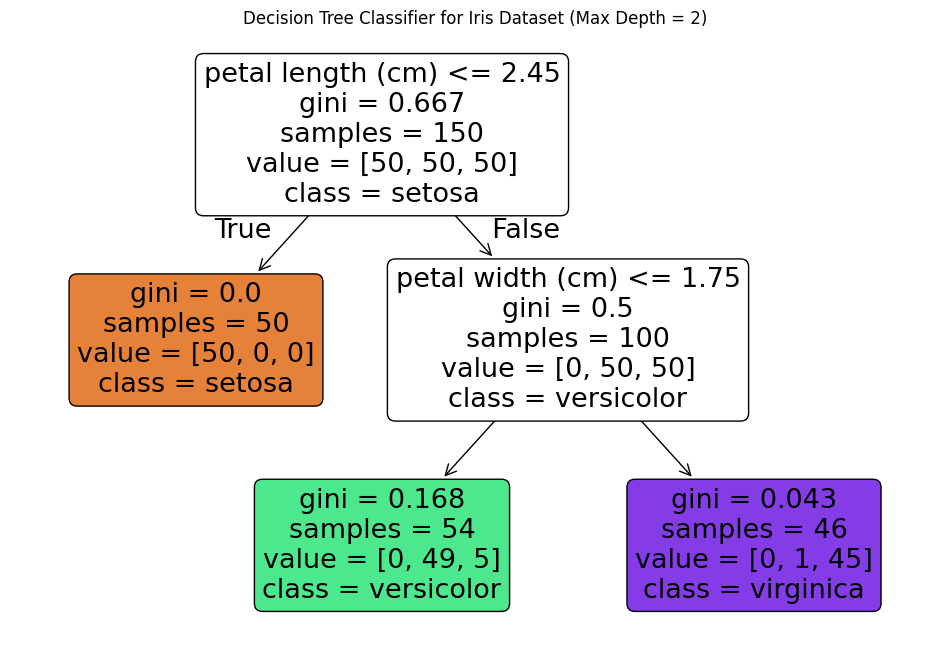

In [13]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

dtc_max_depth_2 = DecisionTreeClassifier(max_depth=2, random_state=42)
dtc_max_depth_2.fit(X_iris, y_iris)

plt.figure(figsize=(12, 8))
plot_tree(dtc_max_depth_2, feature_names=iris.feature_names, class_names=iris.target_names, filled=True, rounded=True)
plt.title("Decision Tree Classifier for Iris Dataset (Max Depth = 2)")
plt.show()

In [14]:
#session 12 4
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

dtc_full = DecisionTreeClassifier(random_state=42)
dtc_full.fit(X_iris, y_iris)

feature_importances = dtc_full.feature_importances_
feature_names = iris.feature_names

importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})
importance_df = importance_df.sort_values(by='importance', ascending=False)

print("Feature Importances (sorted):")
print(importance_df)

Feature Importances (sorted):
             feature  importance
2  petal length (cm)    0.564056
3   petal width (cm)    0.422611
0  sepal length (cm)    0.013333
1   sepal width (cm)    0.000000


## Task: Decision Tree Interpretation on a Sample Dataset

I will use the Wine dataset from scikit-learn as an example of a classification dataset, train a Decision Tree Classifier, and interpret its first three splits.

In [ ]:
#session 12 5
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

wine = load_wine()
X_wine = wine.data
y_wine = wine.target
feature_names_wine = wine.feature_names
class_names_wine = wine.target_names

dtc_wine = DecisionTreeClassifier(max_depth=3, random_state=42)
dtc_wine.fit(X_wine, y_wine)

plt.figure(figsize=(20, 10))
plot_tree(dtc_wine, feature_names=feature_names_wine, class_names=class_names_wine, filled=True, rounded=True)
plt.title("Decision Tree Classifier for Wine Dataset (Max Depth = 3)")
plt.show()

### Interpretation of the First Three Splits:

1.  **First Split (Root Node):**
    *   **Condition:** `proline <= 755.0`
    *   **Explanation:** The tree first splits the data based on the `proline` feature. If the value of `proline` is less than or equal to 755.0, the sample goes to the left child node. Otherwise, it goes to the right child node. `Proline` (a type of amino acid) is a strong discriminator for wine types, suggesting that wines with lower proline content are likely of a certain class (e.g., class 0 or 1), while those with higher proline are likely of another (e.g., class 2).

2.  **Second Split (Left Child of Root):**
    *   **Condition:** `color_intensity <= 3.865`
    *   **Explanation:** For wines where `proline` is less than or equal to 755.0, the tree then uses `color_intensity` to further classify. If `color_intensity` is less than or equal to 3.865, it goes left; otherwise, it goes right. This indicates that among wines with lower proline, `color_intensity` becomes the next important factor to distinguish between classes.

3.  **Third Split (Right Child of Root):**
    *   **Condition:** `od280/od315_of_diluted_wines <= 3.15`
    *   **Explanation:** For wines where `proline` is greater than 755.0 (which leads to the right child of the root), the tree uses `od280/od315_of_diluted_wines` as the splitting criterion. If this value is less than or equal to 3.15, it goes left; otherwise, it goes right. This implies that for wines characterized by high proline, the absorbance of diluted wines becomes crucial for further classification, likely separating out a specific class that has high proline but differing absorbance characteristics.

In [16]:
#session 13
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


print("1")
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(X_iris, y_iris, test_size=0.3, random_state=42)

rf_classifier_iris = RandomForestClassifier(random_state=42)
rf_classifier_iris.fit(X_train_iris, y_train_iris)

y_pred_iris = rf_classifier_iris.predict(X_test_iris)
accuracy_iris = accuracy_score(y_test_iris, y_pred_iris)

print(f"Accuracy on test set: {accuracy_iris:.4f}")


print("2")
np.random.seed(42)
products_data = {
    'price': np.random.randint(100, 5000, 20),
    'rating': np.random.uniform(2.5, 5.0, 20).round(1),
    'brand': np.random.choice(['BrandA', 'BrandB', 'BrandC', 'BrandD'], 20),
    'category': np.random.choice(['Electronics', 'Apparel', 'HomeGoods', 'Books'], 20)
}

df_products = pd.DataFrame(products_data)

df_products_encoded = pd.get_dummies(df_products, columns=['brand'], drop_first=True)

X_products = df_products_encoded.drop('category', axis=1)
y_products = df_products_encoded['category']

rf_product_classifier = RandomForestClassifier(random_state=42)
rf_product_classifier.fit(X_products, y_products)

product_feature_importances = rf_product_classifier.feature_importances_
product_feature_names = X_products.columns

product_importance_df = pd.DataFrame({'feature': product_feature_names, 'importance': product_feature_importances})
product_importance_df = product_importance_df.sort_values(by='importance', ascending=False)

print("Feature Importances (sorted):")
print(product_importance_df)


print("3")
n_estimators_values = [50, 100, 150]
max_depth_values = [5, 10, 15]

best_accuracy = 0
best_params = {}

for n_estimators in n_estimators_values:
    for max_depth in max_depth_values:
        rf_tuned = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
        rf_tuned.fit(X_train_iris, y_train_iris)
        y_pred_tuned = rf_tuned.predict(X_test_iris)
        accuracy_tuned = accuracy_score(y_test_iris, y_pred_tuned)
        print(f"n_estimators: {n_estimators}, max_depth: {max_depth}, Accuracy: {accuracy_tuned:.4f}")
        if accuracy_tuned > best_accuracy:
            best_accuracy = accuracy_tuned
            best_params = {'n_estimators': n_estimators, 'max_depth': max_depth}

print(f"Best accuracy: {best_accuracy:.4f} with parameters: {best_params}")


print("4")
dt_single = DecisionTreeClassifier(random_state=42)
dt_single.fit(X_train_iris, y_train_iris)
y_pred_dt_single = dt_single.predict(X_test_iris)
accuracy_dt_single = accuracy_score(y_test_iris, y_pred_dt_single)

rf_bagging = RandomForestClassifier(random_state=42)
rf_bagging.fit(X_train_iris, y_train_iris)
y_pred_rf_bagging = rf_bagging.predict(X_test_iris)
accuracy_rf_bagging = accuracy_score(y_test_iris, y_pred_rf_bagging)

print(f"Decision Tree Accuracy: {accuracy_dt_single:.4f}")
print(f"Random Forest Accuracy: {accuracy_rf_bagging:.4f}")
print("Bagging in Random Forest helps avoid overfitting by averaging the predictions of multiple decision trees, each trained on a bootstrap sample of the data. This reduces variance and improves generalization compared to a single, potentially overfit, decision tree.")


print("5")
np.random.seed(42)
spotify_data = {
    'tempo': np.random.uniform(60, 180, 100),
    'danceability': np.random.uniform(0.1, 0.9, 100),
    'energy': np.random.uniform(0.1, 0.9, 100),
    'loudness': np.random.uniform(-10, 0, 100),
    'hit': np.random.choice([0, 1], 100, p=[0.6, 0.4])
}
df_spotify = pd.DataFrame(spotify_data)

X_spotify = df_spotify[['tempo', 'danceability', 'energy', 'loudness']]
y_spotify = df_spotify['hit']

X_train_spotify, X_test_spotify, y_train_spotify, y_test_spotify = train_test_split(X_spotify, y_spotify, test_size=0.3, random_state=42)

spotify_rf_classifier = RandomForestClassifier(random_state=42)
spotify_rf_classifier.fit(X_train_spotify, y_train_spotify)

y_pred_spotify = spotify_rf_classifier.predict(X_test_spotify)
accuracy_spotify = accuracy_score(y_test_spotify, y_pred_spotify)

spotify_feature_importances = spotify_rf_classifier.feature_importances_
spotify_feature_names = X_spotify.columns

spotify_importance_df = pd.DataFrame({'feature': spotify_feature_names, 'importance': spotify_feature_importances})
spotify_importance_df = spotify_importance_df.sort_values(by='importance', ascending=False)

print(f"Accuracy on test set: {accuracy_spotify:.4f}")
print("Feature Importances:")
print(spotify_importance_df)

1
Accuracy on test set: 1.0000
2
Feature Importances (sorted):
        feature  importance
0         price    0.455396
1        rating    0.357925
2  brand_BrandB    0.069345
3  brand_BrandC    0.065443
4  brand_BrandD    0.051891
3
n_estimators: 50, max_depth: 5, Accuracy: 1.0000
n_estimators: 50, max_depth: 10, Accuracy: 1.0000
n_estimators: 50, max_depth: 15, Accuracy: 1.0000
n_estimators: 100, max_depth: 5, Accuracy: 1.0000
n_estimators: 100, max_depth: 10, Accuracy: 1.0000
n_estimators: 100, max_depth: 15, Accuracy: 1.0000
n_estimators: 150, max_depth: 5, Accuracy: 1.0000
n_estimators: 150, max_depth: 10, Accuracy: 1.0000
n_estimators: 150, max_depth: 15, Accuracy: 1.0000
Best accuracy: 1.0000 with parameters: {'n_estimators': 50, 'max_depth': 5}
4
Decision Tree Accuracy: 1.0000
Random Forest Accuracy: 1.0000
Bagging in Random Forest helps avoid overfitting by averaging the predictions of multiple decision trees, each trained on a bootstrap sample of the data. This reduces varianc

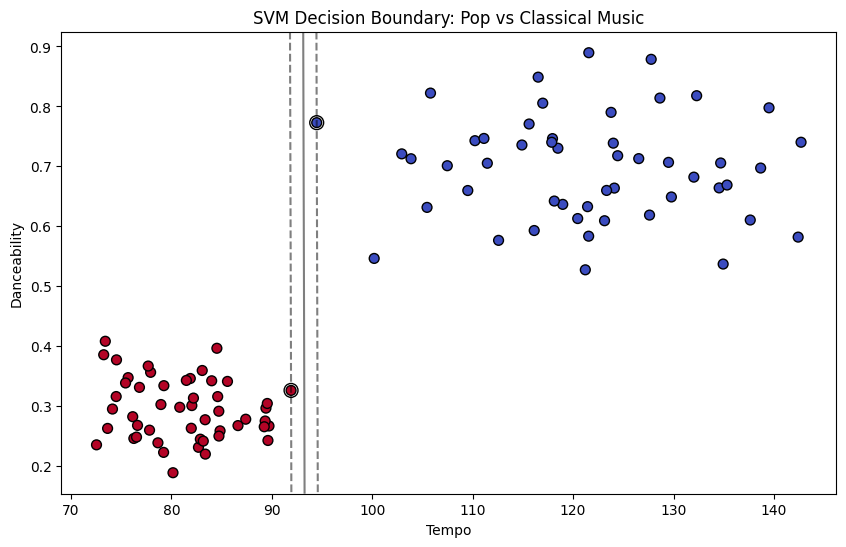

In [17]:
#session 14 1
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

np.random.seed(0)

tempo_pop = np.random.normal(120, 10, 50)
danceability_pop = np.random.normal(0.7, 0.1, 50)

tempo_classical = np.random.normal(80, 5, 50)
danceability_classical = np.random.normal(0.3, 0.05, 50)

X = np.vstack([
    np.column_stack([tempo_pop, danceability_pop]),
    np.column_stack([tempo_classical, danceability_classical])
])
y = np.array([0] * 50 + [1] * 50)

svm_classifier = svm.SVC(kernel='linear', C=1.0)
svm_classifier.fit(X, y)

plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=50, edgecolors='k')

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = svm_classifier.decision_function(xy).reshape(XX.shape)

ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])
ax.scatter(svm_classifier.support_vectors_[:, 0], svm_classifier.support_vectors_[:, 1], s=100, facecolors='none', edgecolors='k')

plt.xlabel('Tempo')
plt.ylabel('Danceability')
plt.title('SVM Decision Boundary: Pop vs Classical Music')
plt.show()

In [18]:
#session 14 2
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

reviews_data = {
    'review': [
        'This product is amazing! I love it.',
        'Terrible quality, very disappointed.',
        'Works great, highly recommended.',
        'Not what I expected, waste of money.',
        'Fantastic value for money, very happy.',
        'Broken on arrival, completely unusable.',
        'Good product, but slow delivery.',
        'Excellent service and fast shipping.',
        'Worst purchase ever, avoid at all costs.',
        'Decent for the price, no complaints.',
        'Absolutely brilliant, exceeded expectations.',
        'Poor design and flimsy build quality.',
        'Highly effective, a must-buy!',
        'Received damaged, total scam.',
        'Best gadget I’ve bought this year.'
    ],
    'sentiment': [
        'positive', 'negative', 'positive', 'negative', 'positive',
        'negative', 'positive', 'positive', 'negative', 'positive',
        'positive', 'negative', 'positive', 'negative', 'positive'
    ]
}

df_reviews = pd.DataFrame(reviews_data)

X = df_reviews['review']
y = df_reviews['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

vectorizer = TfidfVectorizer()
X_train_vectors = vectorizer.fit_transform(X_train)
X_test_vectors = vectorizer.transform(X_test)

svm_classifier = svm.SVC(kernel='linear')
svm_classifier.fit(X_train_vectors, y_train)

y_pred = svm_classifier.predict(X_test_vectors)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy on Flipkart reviews: {accuracy:.4f}")

Accuracy on Flipkart reviews: 0.8000


In [19]:
#session 14 3
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

np.random.seed(42)
player_data = {
    'runs_scored': np.random.randint(0, 150, 100),
    'wickets_taken': np.random.randint(0, 5, 100),
    'strike_rate': np.random.uniform(80, 200, 100),
    'performance_category': np.random.choice(['average', 'good', 'excellent'], 100, p=[0.4, 0.4, 0.2])
}

df_ipl = pd.DataFrame(player_data)

conditions_good = (df_ipl['runs_scored'] > 50) | (df_ipl['wickets_taken'] > 2)
conditions_excellent = (df_ipl['runs_scored'] > 100) | (df_ipl['wickets_taken'] > 3)

df_ipl.loc[conditions_good, 'performance_category'] = 'good'
df_ipl.loc[conditions_excellent, 'performance_category'] = 'excellent'
df_ipl.loc[~conditions_good, 'performance_category'] = 'average'

X = df_ipl[['runs_scored', 'wickets_taken', 'strike_rate']]
y = df_ipl['performance_category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

svm_poly = svm.SVC(kernel='poly', degree=3, C=1.0, random_state=42)
svm_poly.fit(X_train, y_train)
y_pred_poly = svm_poly.predict(X_test)
accuracy_poly = accuracy_score(y_test, y_pred_poly)

svm_rbf = svm.SVC(kernel='rbf', gamma='scale', C=1.0, random_state=42)
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)

print(f"Polynomial Kernel Accuracy: {accuracy_poly:.4f}")
print(f"RBF Kernel Accuracy: {accuracy_rbf:.4f}")

if accuracy_poly > accuracy_rbf:
    print("Polynomial kernel performed better.")
elif accuracy_rbf > accuracy_poly:
    print("RBF kernel performed better.")
else:
    print("Both kernels performed equally.")

Polynomial Kernel Accuracy: 0.6000
RBF Kernel Accuracy: 0.5667
Polynomial kernel performed better.


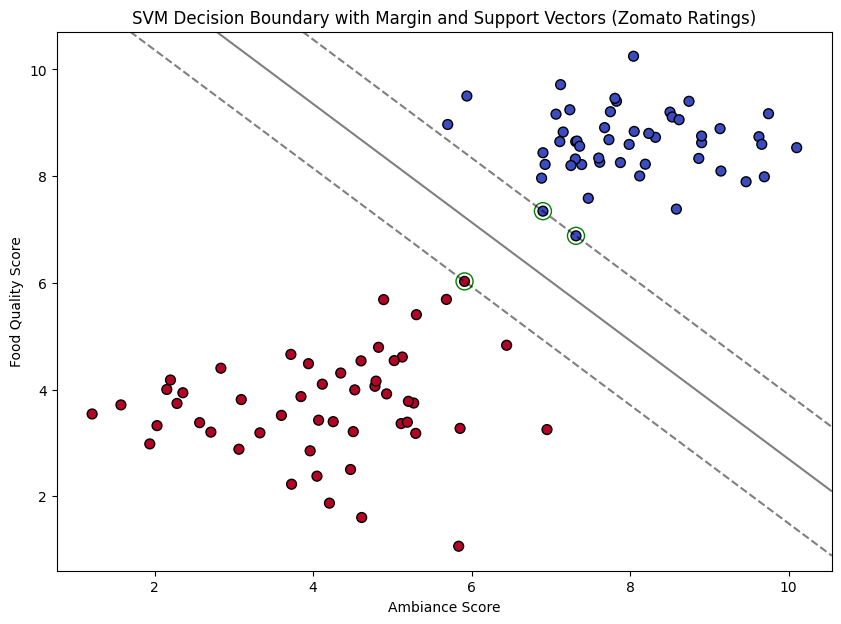

In [20]:
#session 14 4
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

np.random.seed(1)

ambiance_good = np.random.normal(8, 1, 50)
food_good = np.random.normal(8.5, 0.8, 50)

ambiance_bad = np.random.normal(4, 1.5, 50)
food_bad = np.random.normal(3.5, 1, 50)

X = np.vstack([
    np.column_stack([ambiance_good, food_good]),
    np.column_stack([ambiance_bad, food_bad])
])
y = np.array([0] * 50 + [1] * 50)

svm_classifier = svm.SVC(kernel='linear', C=1000)
svm_classifier.fit(X, y)

plt.figure(figsize=(10, 7))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=50, edgecolors='k')

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = svm_classifier.decision_function(xy).reshape(XX.shape)

ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])
ax.scatter(svm_classifier.support_vectors_[:, 0], svm_classifier.support_vectors_[:, 1], s=150, linewidth=1, facecolors='none', edgecolors='green')

plt.xlabel('Ambiance Score')
plt.ylabel('Food Quality Score')
plt.title('SVM Decision Boundary with Margin and Support Vectors (Zomato Ratings)')
plt.show()

In [21]:
#session 15 1
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.3, random_state=42)

gbc_classifier = GradientBoostingClassifier(random_state=42)
gbc_classifier.fit(X_train, y_train)

y_pred = gbc_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"GradientBoostingClassifier Accuracy on Iris Dataset: {accuracy:.4f}")

GradientBoostingClassifier Accuracy on Iris Dataset: 1.0000


In [22]:
#session 15 2
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

reviews_data = {
    'review': [
        'This product is amazing! I love it.',
        'Terrible quality, very disappointed.',
        'Works great, highly recommended.',
        'Not what I expected, waste of money.',
        'Fantastic value for money, very happy.',
        'Broken on arrival, completely unusable.',
        'Good product, but slow delivery.',
        'Excellent service and fast shipping.',
        'Worst purchase ever, avoid at all costs.',
        'Decent for the price, no complaints.',
        'Absolutely brilliant, exceeded expectations.',
        'Poor design and flimsy build quality.',
        'Highly effective, a must-buy!',
        'Received damaged, total scam.',
        'Best gadget I’ve bought this year.'
    ],
    'sentiment': [
        'positive', 'negative', 'positive', 'negative', 'positive',
        'negative', 'positive', 'positive', 'negative', 'positive',
        'positive', 'negative', 'positive', 'negative', 'positive'
    ]
}

df_reviews = pd.DataFrame(reviews_data)

X = df_reviews['review']
y = df_reviews['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

vectorizer = TfidfVectorizer()
X_train_vectors = vectorizer.fit_transform(X_train)
X_test_vectors = vectorizer.transform(X_test)

adaboost_classifier = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), random_state=42)
adaboost_classifier.fit(X_train_vectors, y_train)

y_pred = adaboost_classifier.predict(X_test_vectors)

print("Classification Report for AdaBoostClassifier on Flipkart Reviews:")
print(classification_report(y_test, y_pred))

Classification Report for AdaBoostClassifier on Flipkart Reviews:
              precision    recall  f1-score   support

    negative       1.00      0.50      0.67         2
    positive       0.75      1.00      0.86         3

    accuracy                           0.80         5
   macro avg       0.88      0.75      0.76         5
weighted avg       0.85      0.80      0.78         5



session 15 3
 Weak Learner vs. Strong Learner

A **weak learner** is a model that performs slightly better than random guessing on a classification task. It's often a simple model, like a decision stump (a decision tree with only one split), that has low bias but high variance.

A **strong learner** is a model that achieves high accuracy on a classification task. It is typically a complex model, or an ensemble of weak learners, designed to have low bias and low variance.

**Real-world Examples:**
*   **Weak Learner (from Instagram):** A very simple rule that predicts if a photo will be popular based only on whether it has a filter applied. This single rule is better than random, but far from accurate enough on its own.
*   **Strong Learner (from Zomato):** Zomato's recommendation system for restaurants. It combines many simple signals (like cuisine, average rating, user's past orders, time of day, location, popularity trends) into a complex model to make highly accurate and personalized recommendations.

In [23]:
#session 15 4
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.3, random_state=42)

n_estimators_values = [50, 100, 150]
learning_rate_values = [0.01, 0.1, 0.2]

best_accuracy = 0
best_params = {}

print("Tuning n_estimators and learning_rate for GradientBoostingClassifier:")
for n_estimators in n_estimators_values:
    for learning_rate in learning_rate_values:
        gbc_tuned = GradientBoostingClassifier(n_estimators=n_estimators, learning_rate=learning_rate, random_state=42)
        gbc_tuned.fit(X_train, y_train)
        y_pred_tuned = gbc_tuned.predict(X_test)
        accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
        print(f"n_estimators: {n_estimators}, learning_rate: {learning_rate:.2f}, Accuracy: {accuracy_tuned:.4f}")
        if accuracy_tuned > best_accuracy:
            best_accuracy = accuracy_tuned
            best_params = {'n_estimators': n_estimators, 'learning_rate': learning_rate}

print(f"\nBest accuracy: {best_accuracy:.4f} with parameters: {best_params}")

Tuning n_estimators and learning_rate for GradientBoostingClassifier:
n_estimators: 50, learning_rate: 0.01, Accuracy: 1.0000
n_estimators: 50, learning_rate: 0.10, Accuracy: 1.0000
n_estimators: 50, learning_rate: 0.20, Accuracy: 1.0000
n_estimators: 100, learning_rate: 0.01, Accuracy: 1.0000
n_estimators: 100, learning_rate: 0.10, Accuracy: 1.0000
n_estimators: 100, learning_rate: 0.20, Accuracy: 1.0000
n_estimators: 150, learning_rate: 0.01, Accuracy: 1.0000
n_estimators: 150, learning_rate: 0.10, Accuracy: 1.0000
n_estimators: 150, learning_rate: 0.20, Accuracy: 1.0000

Best accuracy: 1.0000 with parameters: {'n_estimators': 50, 'learning_rate': 0.01}


session 15 5
### Real-world Use Case of Boosting in Indian Apps

**App:** Paytm (Fraud Detection)

Boosting, particularly Gradient Boosting, could significantly enhance Paytm's fraud detection capabilities. By sequentially building weak learners that focus on the errors of previous models, it can identify complex, subtle patterns indicative of fraudulent transactions that a single model might miss. This iterative improvement allows the system to become highly accurate in distinguishing legitimate transactions from fraudulent ones, thereby reducing financial losses for users and the platform, and improving user trust. The ensemble nature provides robustness against various types of fraud.